In [1]:
library("DESeq2")
library("ggplot2")
library("ggrepel")
library("ggcorrplot")
library("dplyr")
library(stringr)
library(purrr)
library("tibble")
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library("pals")
library(ggpubr)
library(tximport)
library(DESeq2)
library("apeglm")
library(patchwork)
library(ggrastr)
library(circlize)

theme_set(
    theme_classic(base_size = 12)
)
source('./plot_data.R')

Warning message:
“package ‘DESeq2’ was built under R version 4.2.3”
Loading required package: S4Vectors

Warning message:
“package ‘S4Vectors’ was built under R version 4.2.3”
Loading required package: stats4

Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.2.1”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:base’:

    exp

In [2]:
final_iso_tb<- read.table("../data/2_final_iso_tb.tsv", sep = "\t", header = T)
length(unique(final_iso_tb$gene_id))
dim(final_iso_tb)[1]

# final number of annotated isoforms: 6292
# final number of annotated genes: 6016

# intron-containing genes
intron_genes<- final_iso_tb  %>% filter(blockCount > 1) %>% pull(gene_id) %>% sort() %>% unique()
final_iso_tb<- final_iso_tb %>% filter(gene_id %in% intron_genes)
length(unique(final_iso_tb$gene_id))
dim(final_iso_tb)[1]

# final number of annotated isoforms: 551
# final number of annotated genes: 275

[1] 6016

[1] 6292

[1] 275

[1] 551

In [3]:
count_all<- read.table(file = '../data/7_nascent_rna_count.tsv', sep = "\t", header = T, row.names = 1, check.names = FALSE)

In [5]:
count<- read.table('../data/rna/nascentRNA/isoquant/260121_nRNA_tx_alignment_annot_by_splicing_isoform_counts.tsv', header = TRUE, sep = "\t")

# reformat to same output with flair
count<- count %>% 
    mutate(iso_id = str_split_i(isoform, ":", 1)) %>% 
    mutate(gene_id = str_split_i(iso_id, "_", 1)) %>%
    mutate(iso = paste0(isoform, "_", gene_id)) %>%
    filter(gene_id %in% intron_genes) %>% 
    select(iso, ys18_rep1, ys18_rep2, ym209_rep1, ym209_rep2) %>% 
    arrange(iso) %>% 
    column_to_rownames(var= "iso") 

colnames(count)<- c("WT rep1", "WT rep2",  "MUT rep1", "MUT rep2")
RPK = count_all/1000
sc_factor = colSums(RPK)/ 1e6
tpm<- countToTPM(count, normalize_by_len = FALSE, scaling_factor = sc_factor)

write.table(x = count, file = '../data/13_nascnet_rna_splicing_count.tsv', sep = "\t", quote = FALSE, col.names = TRUE, row.names = TRUE)
write.table(x = tpm, file = '../data/13_nascent_rna_splicing_tpm.tsv', sep = "\t", quote = FALSE, col.names = TRUE, row.names = TRUE)

## Differential gene expression with limma

In [8]:
library(limma)

Warning message:
“package ‘limma’ was built under R version 4.2.3”

Attaching package: ‘limma’


The following object is masked from ‘package:DESeq2’:

    plotMA


The following object is masked from ‘package:BiocGenerics’:

    plotMA




.
FALSE  TRUE 
 1037   761 

[1] "number of genes : 245"

[1] "number of isoforms: 761"

,groupMUT,groupWT
ACT1:firstExon_ACT1,6.746889,6.061639
ACT1:intronicEnd_ACT1,5.541162,5.799274
ACT1:intronicStart_ACT1,5.102097,4.993258
ACT1:spliced_ACT1,10.581650,10.961425
APE2:antisense_APE2,8.264198,7.639833
APE2:downstream_APE2,8.368965,5.262290


,groupMUT - groupWT
groupMUT,1
groupWT,-1


[1] "antisense"     "downstream"    "firstExon"     "intronic"     
[5] "intronicEnd"   "intronicStart" "IR"            "spliced"

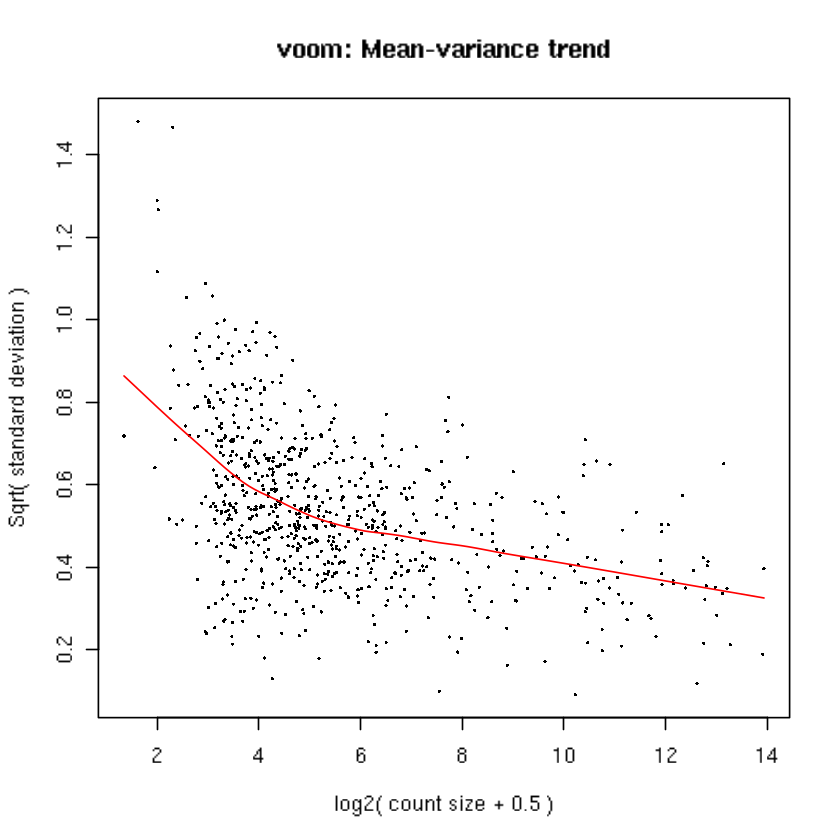

In [21]:
count<- read.table('../data/13_nascnet_rna_splicing_count.tsv', header = T, row.names = 1, sep = '\t')
tpm<- read.table('../data/13_nascent_rna_splicing_tpm.tsv', header = T, row.names = 1, sep = '\t')

smallestGroupSize = 2
smallestCount = 10
keep <- rowSums(count >= smallestCount) >= smallestGroupSize
keep %>% table()
count<- count[keep, ]
tpm<-tpm[keep,]
n_genes<- length(str_split_i(rownames(tpm), ":", 1) %>% sort() %>% unique())
paste0("number of genes : ", n_genes) 
paste0("number of isoforms: ", dim(tpm)[1])


group<- c("WT", "WT", "MUT", "MUT")
mm <- model.matrix(~0 + group)
y <- voom(count, mm, plot = T)

fit <- lmFit(y, mm)
head(coef(fit))

contr <- makeContrasts(groupMUT - groupWT, levels = colnames(coef(fit)))
contr

tmp <- contrasts.fit(fit, contr)
tmp <- eBayes(tmp)

topTable <- topTable(tmp, sort.by = "P", n = Inf)

de_df<- cbind(WT = rowMeans(tpm[, c(1:2)]), MUT = rowMeans(tpm[,c(3,4)])) %>% as.data.frame()
de_df$log2FoldChange = topTable[match(rownames(de_df), rownames(topTable)), "logFC"]
de_df$padj = topTable[match(rownames(de_df), rownames(topTable)), "adj.P.Val"]

de_df = analyzeDESeq_nascent(res_df =  de_df, final_iso_tb$gene_id, padj_cutoff = 0.05, log2fc_cutoff = 0.5, annot_down = 3, annot_up = 3)

de_df$class= final_iso_tb[match(de_df$gene_id, final_iso_tb$gene_id), "class"]
de_df$class<- factor(de_df$class, levels = c('low', 'medium', 'high'))

iso_level<- de_df$feature_id %>% sort() %>% unique()
iso_level
mcolors <- c("#5E8C61FF",
             "#FFC857FF",
             "#D0AF84", 
             "#ADB9A1",
             "#8CBDBC",
             "#F0A96B",
             "#068D9D",
             "#B44E3FFF")
names(mcolors) = iso_level

mcolors_withsig = c(mcolors, "gray")
names(mcolors_withsig)<- c(names(mcolors), "Not sig")

mcol <- c("#80b1d3", "#fb8072", "grey")
names(mcol) <- c("Down in MUT", "Up in MUT", "Not sig")

de_df$feature_id<- factor(de_df$feature_id, levels = iso_level)

write.table(x = de_df, file = '../data/13_nascent_rna_splicing_DE_results.tsv', quote = F, sep = '\t', col.names = T, row.names = T)

Warning message:
“Removed 755 rows containing missing values or values outside the scale range (`geom_text_repel()`).”
Warning message:
“Removed 755 rows containing missing values or values outside the scale range (`geom_text_repel()`).”


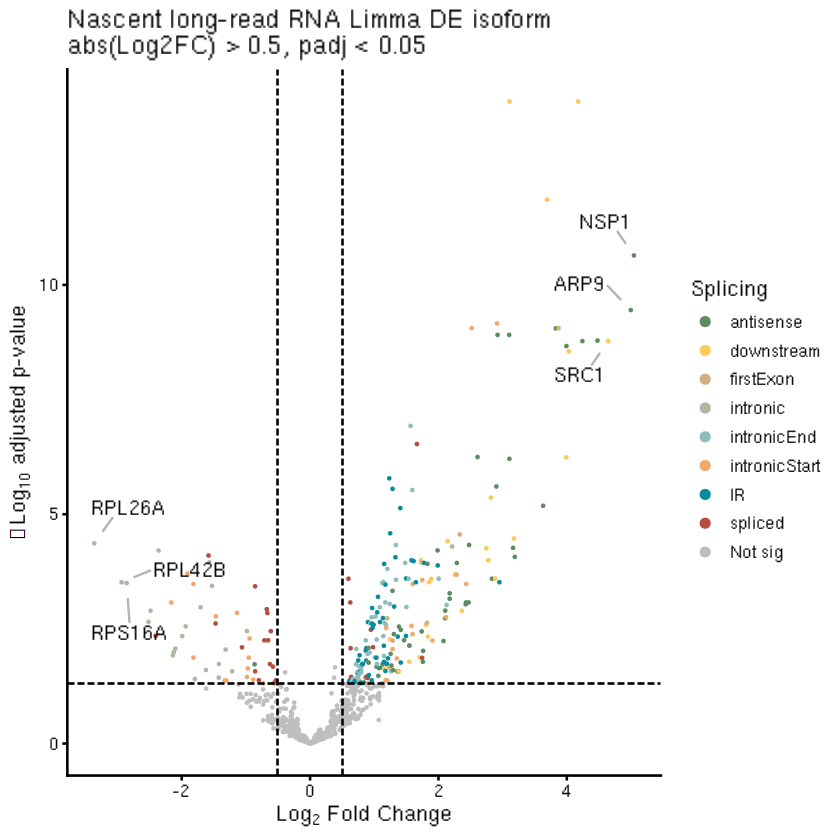

In [54]:
de_df$type = as.character(de_df$feature_id)
de_df[de_df$labels == 'Not sig', 'type'] = 'Not sig'
de_df$type<- factor(de_df$type, levels = c(iso_level, 'Not sig'))
de_df[de_df$padj<10e-15, 'padj'] = 10e-15

p <- de_df %>%
    ggplot(aes(x = log2FoldChange, y = -log10(padj), label = annotation)) +
    geom_point(aes(color = type), size = 0.2) +
    geom_text_repel(box.padding = 1, point.padding = 1, max.overlaps = 5, size = 4, segment.color = "grey70") +
    labs(x = expression(Log[2] * " Fold Change"), y = expression(-Log[10] * " adjusted p-value"), 
       title = "Nascent long-read RNA Limma DE isoform\nabs(Log2FC) > 0.5, padj < 0.05", color = "Splicing")  +
    geom_hline(yintercept = -log10(0.05), color = 'black', linetype = "longdash") +
    geom_vline(xintercept = 0.5, color = 'black', linetype = "longdash") +
    geom_vline(xintercept = -0.5, color = 'black', linetype = "longdash") +
    scale_color_manual(values = mcolors_withsig) +
    guides(color = guide_legend(override.aes = list(size = 2)))
p
ggsave('../figures/Supp_nascent_rna_splicing_isoform_DE_volcano.pdf', width = 5, height = 3)

In [49]:
df1<- de_df %>%
    count(class, labels, name = 'total_per_label') %>% left_join(count(de_df, class, name = 'total'))

df2<- de_df %>%
    count(labels, feature_id, class) %>% 
    left_join(df1, by = join_by(labels, class)) %>% 
    mutate(p_per_label = n/total_per_label, p = n/total)


iso_levels <- df2 %>%
    filter(labels != "Not sig", class == "low", labels == "Up in MUT") %>% 
    arrange(-p) %>% pull(feature_id) %>% as.character()

iso_levels<- c(iso_levels, setdiff(iso_level, iso_levels))
iso_levels


write.table(df2 %>% select(class, feature_id, labels, n, total_per_label, total, p_per_label, p),
          '../data/13_nascent_rna_splicing_DE_fraction_by_expr.tsv', quote = F, sep = '\t', col.names = T, row.names = F)

Joining with `by = join_by(class)`


[1] "antisense"     "intronicStart" "downstream"    "IR"           
[5] "firstExon"     "spliced"       "intronic"      "intronicEnd"

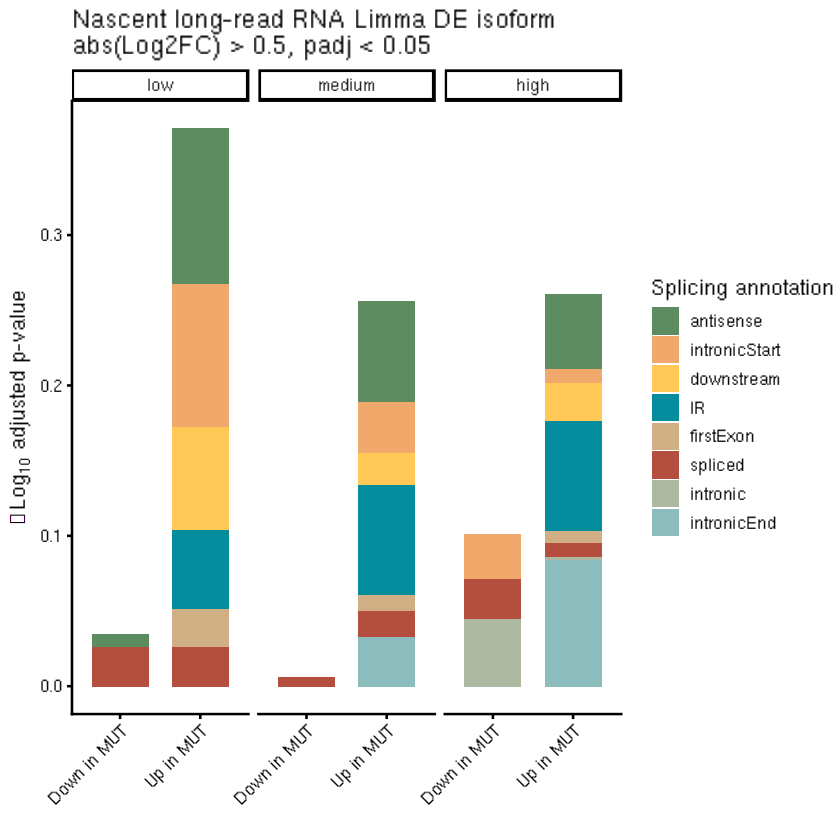

In [50]:
p1<- df2 %>%
    mutate(feature_id = factor(feature_id, levels = iso_levels),
           labels = factor(labels, levels = c("Down in MUT", "Up in MUT", "Not sig"))) %>% 
    ggplot(aes(x = labels, y = p, fill = feature_id)) +
    geom_bar(stat='identity', position = "stack", width=0.7) +
    scale_fill_manual(values = mcolors) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    labs(x = "", y = expression(-Log[10] * " adjusted p-value"), 
         title = "Nascent long-read RNA Limma DE isoform\nabs(Log2FC) > 0.5, padj < 0.05", fill = "Splicing annotation")  +
    facet_wrap(vars(class), ncol = 3)

ggsave("../figures/Supp_nascent_rna_splicing_percentage_of_isoform_by_expr_with_sig.pdf", p1, width = 6, height = 3)

p2<- df2 %>%
    mutate(feature_id = factor(feature_id, levels = iso_levels),
           labels = factor(labels, levels = c("Down in MUT", "Up in MUT", "Not sig"))) %>% 
    filter(labels != "Not sig") %>% 
    ggplot(aes(x = labels, y = p, fill = feature_id)) +
    geom_bar(stat='identity', position = "stack", width=0.7) +
    scale_fill_manual(values = mcolors) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    labs(x = "", y = expression(-Log[10] * " adjusted p-value"), 
         title = "Nascent long-read RNA Limma DE isoform\nabs(Log2FC) > 0.5, padj < 0.05", fill = "Splicing annotation") +
    facet_wrap(vars(class), ncol = 3) 
p2
ggsave("../figures/Supp_nascent_rna_splicing_percentage_of_isoform_by_expr.pdf", p2, width = 6, height = 3)

Joining with `by = join_by(labels)`


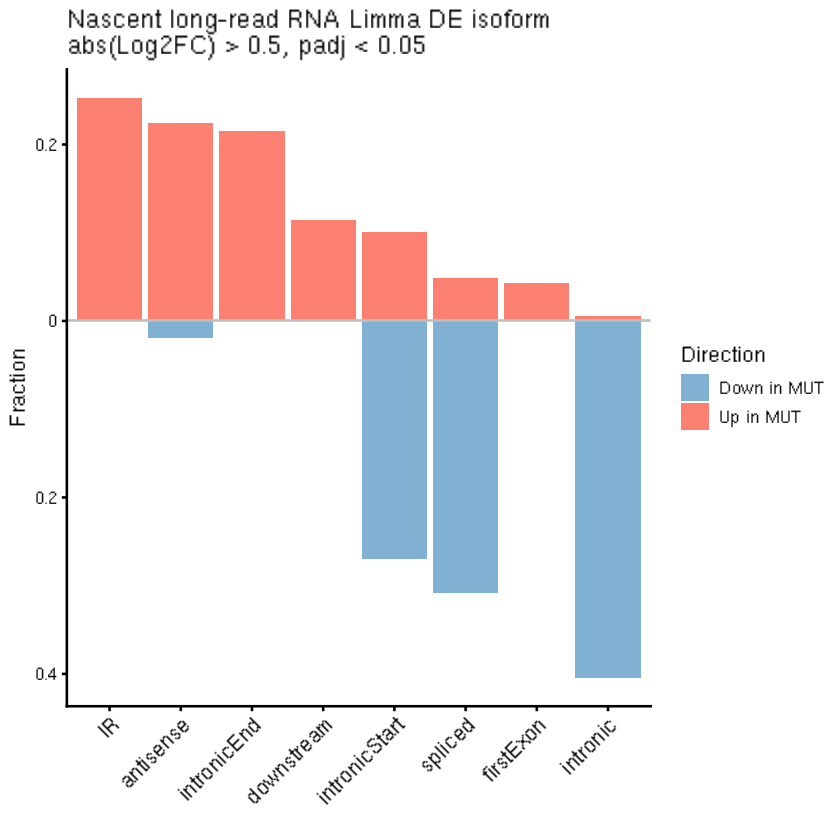

In [52]:
df<- de_df %>%
    count(labels, name = 'total_per_label') %>%
    left_join(count(de_df, labels, feature_id, name = 'feature_per_label')) %>% 
    mutate(frac = feature_per_label/total_per_label) %>% 
    mutate(frac = ifelse(labels == "Down in MUT", -frac, frac)) %>% 
    filter(labels != "Not sig")

order = df %>% arrange(-frac) %>% pull(feature_id) %>% unique()

df$feature_id<- factor(df$feature_id, levels = order)


df %>% 
    ggplot(aes(x = feature_id, y = frac, fill = labels)) +
    geom_col() +
    scale_fill_manual(values = c("Down in MUT" = "#80b1d3", "Up in MUT" = "#fb8072")) +
    scale_y_continuous(labels = function(x) abs(x)) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 12)) +
    geom_hline(yintercept = 0, color = "Gray") +
    labs(x = "", y = "Fraction", fill = "Direction",
         title ="Nascent long-read RNA Limma DE isoform\nabs(Log2FC) > 0.5, padj < 0.05")

ggsave('../figures/Supp_nascent_rna_isoform_DE_fraction.pdf', width = 5, height = 3.5)

In [53]:
all_genes<- de_df$gene_id %>% sort() %>% unique()
ds_genes<- de_df %>% distinct(labels, gene_id) %>% filter(labels != "Not sig") %>% pull(gene_id) %>% sort() %>% unique()
ds_genes
write.table(x = ds_genes, file = "../data/13_nascent_rna_splicing_all_DE_isoforms_geneid.tsv", sep = "\t", quote = F, col.names = F, row.names = F)

[1] "APE2"      "ARF2"      "ARP2"      "ARP9"      "BCK2"      "BET4"     
  [7] "BMH2"      "CIN2"      "COF1"      "COX4"      "COX5B"     "CPT1"     
 [13] "DBP2"      "DYN2"      "ECM9"      "EPT1"      "GCR1"      "GIM4"     
 [19] "GOT1"      "GPI15"     "HFM1"      "HNT1"      "HNT2"      "HPC2"     
 [25] "HRB1"      "KIN28"     "MAF1"      "MCR1"      "MEI4"      "MPT5"     
 [31] "MRM2"      "MRPL44"    "NBL1"      "NHP6B"     "NSP1"      "OSW2"     
 [37] "PBA1"      "PCH2"      "PFY1"      "PRE3"      "PRP5"      "PTC7"     
 [43] "REC114"    "RFA2"      "RPL13B"    "RPL14B"    "RPL16A"    "RPL18A"   
 [49] "RPL18B"    "RPL19A"    "RPL19B"    "RPL20B"    "RPL21A"    "RPL21B"   
 [55] "RPL22A"    "RPL22B"    "RPL23B"    "RPL24A"    "RPL24B"    "RPL25"    
 [61] "RPL26A"    "RPL27A"    "RPL27B"    "RPL28"     "RPL2A"     "RPL2B"    
 [67] "RPL31B"    "RPL32"     "RPL33A"    "RPL34A"    "RPL34B"    "RPL35A"   
 [73] "RPL35B"    "RPL36A"    "RPL36B"    "RPL37A"    "RPL37B"    "RPL39"    
 [79] "RPL40A"    "RPL40B"    "RPL42A"    "RPL42B"    "RPL43B"    "RPL6B"    
 [85] "RPP1B"     "RPS0B"     "RPS10B"    "RPS11A"    "RPS11B"    "RPS13"    
 [91] "RPS14A"    "RPS14B"    "RPS16A"    "RPS16B"    "RPS17A"    "RPS17B"   
 [97] "RPS18A"    "RPS18B"    "RPS19A"    "RPS19B"    "RPS21A"    "RPS21B"   
[103] "RPS23A"    "RPS24A"    "RPS24B"    "RPS25A"    "RPS26A"    "RPS26B"   
[109] "RPS27A"    "RPS27B"    "RPS29A"    "RPS29B"    "RPS30A"    "RPS30B"   
[115] "RPS6A"     "RPS6B"     "RPS8A"     "RPS8B"     "RPS9A"     "RPS9B"    
[121] "RRT8"      "RUB1"      "SAR1"      "SCS22"     "SEC27"     "SIM1"     
[127] "SMD2"      "SNR17A"    "SNR17B"    "SPO1"      "SPO22"     "SRC1"     
[133] "SUN4"      "TAD3"      "TAN1"      "TFC3"      "TUB3"      "UBC8"     
[139] "USV1"      "VPS75"     "YCL012C"   "YDR381C-A" "YGR001C"   "YKR005C"  
[145] "YLR211C"   "YOP1"      "YPL109C"   "YPR170W-B" "YRA1"      "YSC84"